This notebook is for reproducing all results reported in paper "Conversations Gone Awry, But Then? Evaluating Conversational Forecasting Models".
The results include:
1. Performance of TransformerEncoderModels (BERT-base, BERT-large, RoBERTa-base, RoBERTa-large, SpanBERT-base, SpanBERT-large, DeBERTaV3-base, and DeBERTaV3-large)
2. Performance of TransformerDecoderModels (Gemma2 9B, LlaMA3.1 8B, Mistral 7B, and Phi4 14B)

In [2]:
import unsloth

from convokit.utterance_simulator.unslothUtteranceSimulatorModel import UnslothUtteranceSimulatorModel
from convokit.utterance_simulator.utteranceSimulator import UtteranceSimulator

from convokit import (download,
                      Corpus,
                      Forecaster,
                      TransformerEncoderModel,
                      TransformerDecoderModel,
                      TransformerForecasterConfig,
)
import tarfile
import json, os, shutil
import re
import urllib.request
from urllib.parse import urljoin, urlparse
import copy

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/reef/lyk25/ConvoKit/dist/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1782619476.409075 1013993 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782619476.481779 1013993 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782619477.990444 1013993 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due t

🦥 Unsloth Zoo will now patch everything to make training faster!


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


### Define datasets and working directories 

In [3]:
# CPU mode (noting that it will be slower)
DEVICE = "cuda"

# corpus_name = "cga-wikiconv"
# corpus_name = "cga-cmv-legacy"
corpus_name = "cga-cmv-large"
label_metadata = "has_removed_comment" if 'cmv' in corpus_name else 'conversation_has_personal_attack'

YOUR_MODEL_DIRECTORY = "YOUR_MODEL_DIRECTORY"
YOUR_SAVING_DIRECTORY = "YOUR_SAVING_DIRECTORY"

In [4]:
if corpus_name == "cga-wikiconv":
    corpus = Corpus(filename=download("conversations-gone-awry-corpus"))
elif corpus_name == "cga-cmv-legacy":
    corpus = Corpus(filename=download("conversations-gone-awry-cmv-corpus"))
elif corpus_name == "cga-cmv-large":
    corpus = Corpus(filename=download("conversations-gone-awry-cmv-corpus-large"))

Dataset already exists at /reef/lyk25/ConvoKit/examples/forecaster/conversations-gone-awry-cmv-corpus-large


### Download Fine-tuned Models

In [7]:
def is_directory(href):
    return href.endswith('/')

def list_links(url):
    """list files and directories from an apache-style directory listing."""
    response = urllib.request.urlopen(url)
    html = response.read().decode('utf-8')
    return re.findall(r'href="([^"?][^"]*)"', html)

def download_file(file_url, dest_path):
    if os.path.exists(dest_path):
        print(f"skipped existing: {dest_path}")
        return
    urllib.request.urlretrieve(file_url, dest_path)

def download_recursive(base_url, base_folder, root_url=None):
    if root_url is None:
        root_url = base_url
    links = list_links(base_url)
    for href in links:
        if href in ('../',):  # skip parent link
            continue
        full_url = urljoin(base_url, href)
        parsed = urlparse(full_url)
        relative_path = parsed.path.replace(urlparse(root_url).path, '').lstrip('/')
        local_path = os.path.join(base_folder, relative_path)

        if is_directory(href):
            os.makedirs(local_path, exist_ok=True)
            download_recursive(full_url, base_folder, root_url=root_url)
        else:
            os.makedirs(os.path.dirname(local_path), exist_ok=True)
            download_file(full_url, local_path)


In [5]:
MODEL = "bert-base-cased"

**List of Models**

**TransformerEncoderModel**
- `bert-base-cased` — BERT-base  
- `roberta-base` — RoBERTa-base  
- `SpanBERT/spanbert-base-cased` — SpanBERT-base  
- `microsoft/deberta-v3-base` — DeBERTaV3-base  
- `bert-large-cased` — BERT-large  
- `roberta-large` — RoBERTa-large  
- `SpanBERT/spanbert-large-cased` — SpanBERT-large  
- `microsoft/deberta-v3-large` — DeBERTaV3-large  

**TransformerDecoderModel**
- `google/gemma-2-9b-it` — Gemma2 9B  
- `meta-llama/Llama-3.1-8B-Instruct` — LLaMA 3.1 8B  
- `mistralai/Mistral-7B-Instruct-v0.3` — Mistral 7B  
- `microsoft/phi-4` — Phi-4 14B

In [ ]:
BASE_URL = f"https://zissou.infosci.cornell.edu/convokit/models/forecaster_models/{corpus_name}/{MODEL}/"
DOWNLOAD_DIR = f"{YOUR_MODEL_DIRECTORY}/{corpus_name}/{MODEL}"

os.makedirs(DOWNLOAD_DIR, exist_ok=True)
download_recursive(BASE_URL, DOWNLOAD_DIR)
forecasting_models_path = DOWNLOAD_DIR


## Define selectors for the Forecaster

Core to the flexibility of the `Forecaster` framework is the concept of *selectors*. 

To capture the temporal dimension of the conversational forecasting task, `Forecaster` iterates through conversations in chronological utterance order, at each step presenting to the backend forecasting model a "context tuple" containing both the comment itself and the full "context" preceding that comment. As a general framework, `Forecaster` on its own does not try to make any further assumptions about what "context" should contain or look like; it simply presents context as a chronologically ordered list of all utterances up to and including the current one. 

In [13]:
def transform_selector(context_tuple):
    """
    For transform we only need to check that the conversation is in the test split
    """
    
    convo = context_tuple.current_utterance.get_conversation()
    convo_length = len(convo.get_chronological_utterance_list())

    matches_split = (context_tuple.current_utterance.get_conversation().meta["split"] == "test")
    is_end = (len(context_tuple.context) == convo_length)

    if "cmv" in corpus_name:
        return (matches_split)
    else:
        return (matches_split and not is_end)
    
def update_metrics(all_results, cur_metrics):
    for metric in cur_metrics:
        all_results[metric] = all_results.get(metric, []) + [cur_metrics[metric]]
    return all_results

# Transformer Encoder-based Forecaster

Evaluating Random Seed 1
100%|██████████| 5131/5131 [00:47<00:00, 109.11it/s]


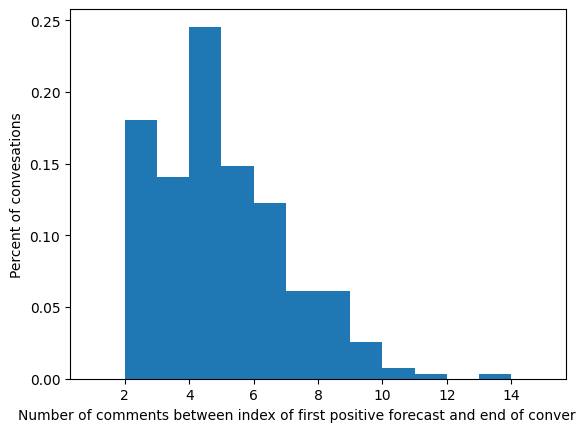

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 3.5899280575539567, Median = 3.0
Accuracy                                                         0.661905
Precision                                                        0.661905
Recall                                                           0.661905
FPR                                                              0.338095
F1                                                               0.661905
Mean H                                                           3.589928
Correct Adjustment                                                   0.05
Incorrect Adjustment                                             0.066667
Recovery                                                        -0.016667
Leaderboard String      | MODEL_NAME     | 66.2   | 66.2  | 66.2 | 66....
dtype: object
Evaluating Random Seed 2
100%|██████████| 5131/5131 [00:47<00:00, 108.70it/s]


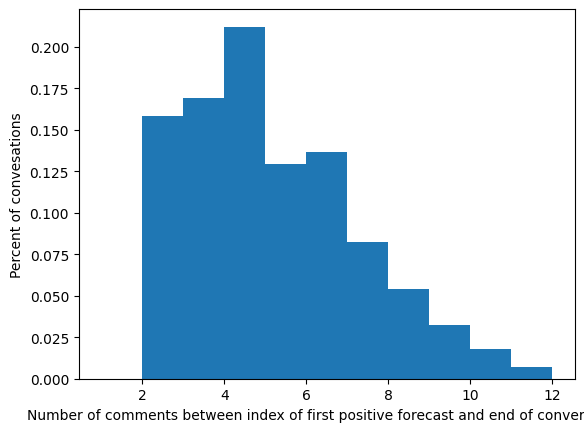

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 3.731182795698925, Median = 3.0
Accuracy                                                         0.666667
Precision                                                        0.667464
Recall                                                           0.664286
FPR                                                              0.330952
F1                                                               0.665871
Mean H                                                           3.731183
Correct Adjustment                                               0.054762
Incorrect Adjustment                                              0.07619
Recovery                                                        -0.021429
Leaderboard String      | MODEL_NAME     | 66.7   | 66.7  | 66.4 | 66....
dtype: object
Evaluating Random Seed 3
100%|██████████| 5131/5131 [00:47<00:00, 109.03it/s]


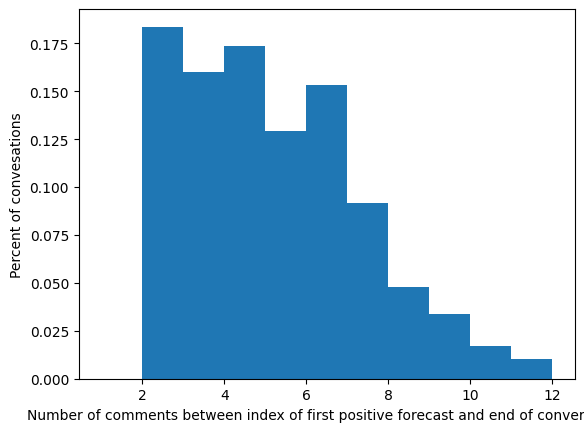

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 3.7491525423728813, Median = 3.0
Accuracy                                                         0.672619
Precision                                                        0.662921
Recall                                                           0.702381
FPR                                                              0.357143
F1                                                               0.682081
Mean H                                                           3.749153
Correct Adjustment                                               0.070238
Incorrect Adjustment                                             0.088095
Recovery                                                        -0.017857
Leaderboard String      | MODEL_NAME     | 67.3   | 66.3  | 70.2 | 68....
dtype: object
Evaluating Random Seed 4
100%|██████████| 5131/5131 [00:47<00:00, 108.49it/s]


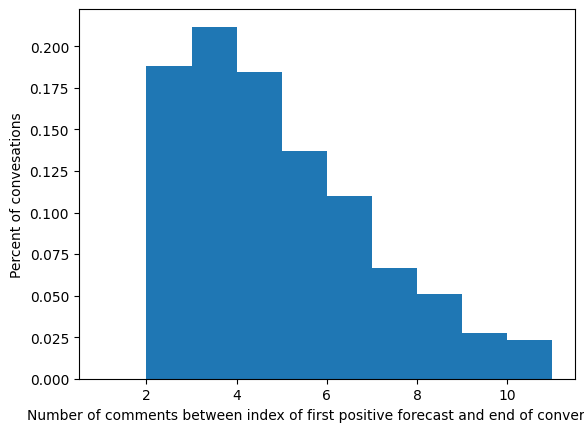

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 3.484375, Median = 3.0
Accuracy                                                         0.642857
Precision                                                        0.653061
Recall                                                           0.609524
FPR                                                               0.32381
F1                                                               0.630542
Mean H                                                           3.484375
Correct Adjustment                                               0.055952
Incorrect Adjustment                                             0.060714
Recovery                                                        -0.004762
Leaderboard String      | MODEL_NAME     | 64.3   | 65.3  | 61.0 | 63....
dtype: object
Evaluating Random Seed 5
100%|██████████| 5131/5131 [00:47<00:00, 108.92it/s]


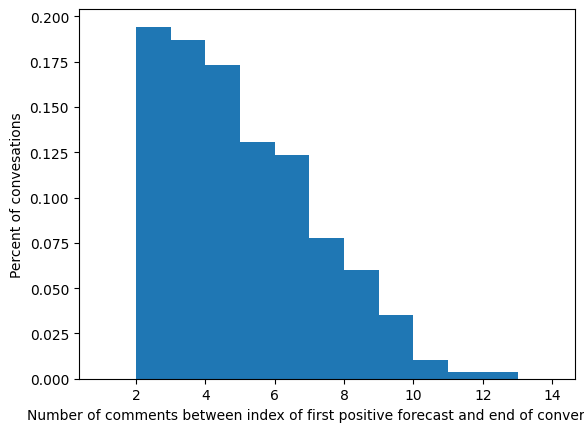

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 3.605633802816901, Median = 3.0
Accuracy                                                         0.678571
Precision                                                        0.679426
Recall                                                            0.67619
FPR                                                              0.319048
F1                                                               0.677804
Mean H                                                           3.605634
Correct Adjustment                                                   0.05
Incorrect Adjustment                                             0.070238
Recovery                                                        -0.020238
Leaderboard String      | MODEL_NAME     | 67.9   | 67.9  | 67.6 | 67....
dtype: object
{'Accuracy': np.float64(0.6645238095238095), 'Precision': np.float64(0.6649554573724549), 'Recall': np.float64(0.66285

In [10]:
all_results = {}
for seed in range(1,6):
    print(f"Evaluating Random Seed {seed}")
    config_dict = TransformerForecasterConfig(
        output_dir=f"{YOUR_SAVING_DIRECTORY}/{corpus_name}/{MODEL}/seed{seed}",
        context_mode="normal", # set to normal by default
        device=DEVICE
    )
    saved_model_path = os.path.join(forecasting_models_path, f'seed-{seed}')

    #Load pre-tuned config
    tuned_config_file = os.path.join(saved_model_path, "dev_config.json")
    with open(tuned_config_file, 'r') as file:
        tuned_config = json.load(file)

    encoder_model = TransformerEncoderModel(os.path.join(saved_model_path, tuned_config['best_checkpoint']), config=config_dict)
    encoder_model.best_threshold = tuned_config['best_threshold']
    encoder_forecaster = Forecaster(encoder_model, label_metadata)

    # corpus = copy.deepcopy(corpus)
    corpus = encoder_forecaster.transform(corpus, transform_selector)
    _, cur_metrics= encoder_forecaster.summarize(corpus, lambda c: c.meta['split'] == "test")

    update_metrics(all_results, cur_metrics)

for metric in all_results:
    if metric == "Leaderboard String":
        continue
    all_results[metric] = sum(all_results[metric]) / len(all_results[metric])

print(all_results)

In [11]:
leaderboard_string = (f"| BERT-base     | "
                              f"{all_results['Accuracy']*100:.1f}   | "
                              f"{all_results['Precision']*100:.1f}  | "
                              f"{all_results['Recall']*100:.1f} | "
                              f"{all_results['F1']*100:.1f}  | "
                              f"{all_results['FPR']*100:.1f}   | "
                              f"{all_results['Mean H']:.2f} | "
                              f"{(all_results['Correct Adjustment']-all_results['Incorrect Adjustment'])*100:.1f} "
                              f"({all_results['Correct Adjustment']*100:.1f} - {all_results['Incorrect Adjustment']*100:.1f})  |")
all_results['Leaderboard String'] = leaderboard_string
print(json.dumps(all_results, indent=4))


{
    "Accuracy": 0.6645238095238095,
    "Precision": 0.6649554573724549,
    "Recall": 0.6628571428571428,
    "FPR": 0.33380952380952383,
    "F1": 0.6636405952685067,
    "Mean H": 3.6320544396885324,
    "Correct Adjustment": 0.05619047619047619,
    "Incorrect Adjustment": 0.07238095238095239,
    "Recovery": -0.016190476190476193,
    "Leaderboard String": "| BERT-base     | 66.5   | 66.5  | 66.3 | 66.4  | 33.4   | 3.63 | -1.6 (5.6 - 7.2)  |"
}


# Transformer Decoder-based Forecaster

In [8]:
MODEL = "google/gemma-2-9b-it"
BASE_URL = f"https://zissou.infosci.cornell.edu/convokit/models/forecaster_models/{corpus_name}/{MODEL}/"
DOWNLOAD_DIR = f"{YOUR_MODEL_DIRECTORY}/{corpus_name}/{MODEL}"

os.makedirs(DOWNLOAD_DIR, exist_ok=True)
download_recursive(BASE_URL, DOWNLOAD_DIR)
forecasting_models_path = DOWNLOAD_DIR

skipped existing: YOUR_MODEL_DIRECTORY/cga-cmv-large/google/gemma-2-9b-it/seed-1/checkpoint-736/README.md
skipped existing: YOUR_MODEL_DIRECTORY/cga-cmv-large/google/gemma-2-9b-it/seed-1/checkpoint-736/adapter_config.json
skipped existing: YOUR_MODEL_DIRECTORY/cga-cmv-large/google/gemma-2-9b-it/seed-1/checkpoint-736/adapter_model.safetensors
skipped existing: YOUR_MODEL_DIRECTORY/cga-cmv-large/google/gemma-2-9b-it/seed-1/checkpoint-736/optimizer.pt
skipped existing: YOUR_MODEL_DIRECTORY/cga-cmv-large/google/gemma-2-9b-it/seed-1/checkpoint-736/rng_state.pth
skipped existing: YOUR_MODEL_DIRECTORY/cga-cmv-large/google/gemma-2-9b-it/seed-1/checkpoint-736/scheduler.pt
skipped existing: YOUR_MODEL_DIRECTORY/cga-cmv-large/google/gemma-2-9b-it/seed-1/checkpoint-736/special_tokens_map.json
skipped existing: YOUR_MODEL_DIRECTORY/cga-cmv-large/google/gemma-2-9b-it/seed-1/checkpoint-736/tokenizer.json
skipped existing: YOUR_MODEL_DIRECTORY/cga-cmv-large/google/gemma-2-9b-it/seed-1/checkpoint-736/t

In [ ]:
# This cell takes around 80 mins on a single NVIDIA RTX A6000
all_results = {}
for seed in range(1,6):
    print(f"Evaluating Random Seed {seed}")
    config_dict = TransformerForecasterConfig(
        output_dir=f"{YOUR_SAVING_DIRECTORY}/{corpus_name}/{MODEL}/seed{seed}",
        context_mode="normal", # set to normal by default
        device=DEVICE
    )
    saved_model_path = os.path.join(forecasting_models_path, f'seed-{seed}')

    #Load pre-tuned config
    tuned_config_file = os.path.join(saved_model_path, "dev_config.json")
    with open(tuned_config_file, 'r') as file:
        tuned_config = json.load(file)

    decoder_model = TransformerDecoderModel(os.path.join(saved_model_path, tuned_config['best_checkpoint']), config=config_dict)
    decoder_model.best_threshold = tuned_config['best_threshold']
    decoder_model.decision_policy.reuse_cached_forecast_probs = False
    decoder_forecaster = Forecaster(decoder_model, label_metadata)

    corpus = decoder_forecaster.transform(corpus, transform_selector)
    _, cur_metrics= decoder_forecaster.summarize(corpus, lambda c: c.meta['split'] == "test")

    update_metrics(all_results, cur_metrics)

for metric in all_results:
    if metric == "Leaderboard String":
        continue
    all_results[metric] = sum(all_results[metric]) / len(all_results[metric])


In [ ]:
leaderboard_string = (f"| Gemma2-9B     | "
                              f"{all_results['Accuracy']*100:.1f}   | "
                              f"{all_results['Precision']*100:.1f}  | "
                              f"{all_results['Recall']*100:.1f} | "
                              f"{all_results['F1']*100:.1f}  | "
                              f"{all_results['FPR']*100:.1f}   | "
                              f"{all_results['Mean H']:.2f} | "
                              f"{(all_results['Correct Adjustment']-all_results['Incorrect Adjustment'])*100:.1f} "
                              f"({all_results['Correct Adjustment']*100:.1f} - {all_results['Incorrect Adjustment']*100:.1f})  |")
all_results['Leaderboard String'] = leaderboard_string
print(json.dumps(all_results, indent=4))

## With DeferralDecisionPolicy

We can also try attaching a DeferralDecisionPolicy to the same model.

In [5]:
from functools import partial

In [6]:
SIMULATOR_TRAIN_CONFIG = {
    "per_device_train_batch_size": 16,
    "per_device_eval_batch_size": 16,
    "eval_strategy": "steps",
    "save_strategy": "steps",
    "save_steps": 30,
    "gradient_accumulation_steps": 4,
    "warmup_steps": 5,
    "num_train_epochs": 1,
    "eval_steps": 30,
    "learning_rate": 2e-4,
    "logging_steps": 5,
    "optim": "adamw_8bit",
    "weight_decay": 0.01,
    "lr_scheduler_type": "linear",
    "output_dir": "outputs/simulator_finetune",
    "logging_dir": "logs",
    "load_best_model_at_end": True,
}

In [7]:
TAU = 7
DEFERRAL_PROBABILITY_THRESHOLD = 0.2518938553561718
NUM_SIMULATIONS = 10
OUTPUT_DIR = "benchmark_preannotated"
SEEDS = [1,2,3,4,5]

In [8]:
def context_selector(context_tuple, split):
    """
    We use this generic function for both training and validation data.
    In both cases, its job is to select only those contexts for which the
    FUTURE context is not empty, so we have a next utterance to predict.
    """
    matches_split = (context_tuple.current_utterance.get_conversation().meta.get("split") == split)
    is_end = (len(context_tuple.future_context) == 0)
    return matches_split and not is_end

def make_data_selector(split):
    return lambda context_tuple: context_tuple.current_utterance.get_conversation().meta.get("split") == split

train_context_selector = partial(context_selector, split="train")
val_context_selector = partial(context_selector, split="val")
test_context_selector = partial(context_selector, split="test")

In [9]:
simulator_model = UnslothUtteranceSimulatorModel(
    train_config=SIMULATOR_TRAIN_CONFIG,
)

==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 4.57.6. vLLM: 0.10.2.
   \\   /|    NVIDIA RTX A6000. Num GPUs = 1. Max memory: 47.536 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Offloading input_embeddings to disk to save VRAM
/reef/conda-envs/lyk25-env/lib/python3.11/site-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)
Unsloth 2026.

In [ ]:
from convokit.decisionpolicy import DeferralDecisionPolicy

all_results = {}
for seed in range(1,6):
    print(f"Evaluating Random Seed {seed}")
    config_dict = TransformerForecasterConfig(
        output_dir=f"{YOUR_SAVING_DIRECTORY}/{corpus_name}/{MODEL}/seed{seed}",
        context_mode="normal", # set to normal by default
        device=DEVICE
    )
    saved_model_path = os.path.join(forecasting_models_path, f'seed-{seed}')

    #Load pre-tuned config
    tuned_config_file = os.path.join(saved_model_path, "dev_config.json")
    with open(tuned_config_file, 'r') as file:
        tuned_config = json.load(file)

    decoder_model = TransformerDecoderModel(os.path.join(saved_model_path, tuned_config['best_checkpoint']), config=config_dict)
    decoder_model.decision_policy = DeferralDecisionPolicy(
        simulator=simulator_model,
        threshold=tuned_config['best_threshold'],
        tau=TAU,
    )
    decoder_model.decision_policy.reuse_cached_forecast_probs = False
    decoder_model.best_threshold = tuned_config['best_threshold']
    decoder_forecaster = Forecaster(decoder_model, label_metadata)

    # corpus = copy.deepcopy(corpus)
    corpus = decoder_forecaster.transform(corpus, transform_selector)
    _, cur_metrics= decoder_forecaster.summarize(corpus, lambda c: c.meta['split'] == "test")

    update_metrics(all_results, cur_metrics)

for metric in all_results:
    if metric == "Leaderboard String":
        continue
    all_results[metric] = sum(all_results[metric]) / len(all_results[metric])
